# HeatmapPlot

`HeatmapPlot` visualises thermal comfort model output on a 2-D temporal grid:
- **Y-axis**: hour of day (0 at the bottom, 24 at the top)
- **X-axis**: day of year (month or day labels)
- **Cell colour**: threshold region the value falls in
- **Blank cells**: NaN / missing data

The same `set_regions()` API is used across `ThresholdPlot`, `SummaryPlot`, and `HeatmapPlot`, so the same thresholds, labels, and colours work across all three.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pythermalcomfort.models import pmv_ppd_iso
from pythermalcomfort.plots.matplotlib import HeatmapPlot, SummaryPlot

## 1.  Generate synthetic annual hourly data

Example of a mechanically ventilated **office building** in a temperate climate (e.g. central Europe):
- Indoor temperature is HVAC-controlled (setpoint ~22 °C) with a slight seasonal drift and a small afternoon peak from solar gains.
- Clothing insulation follows a seasonal schedule: 1.0 clo in winter, 0.5 clo in summer.
- All inputs stay within the ISO 7730 PMV applicability limits, so no NaN values are expected.


In [26]:
rng = np.random.default_rng(42)

index = pd.date_range("2024-01-01", periods=8760, freq="h")
doy  = index.day_of_year.to_numpy()
hour = index.hour.to_numpy()

# Indoor dry-bulb temperature (°C)
# HVAC setpoint drifts from 21 °C (winter) to 24 °C (summer peak)
t_seasonal = 22.5 + 4.5 * np.sin(2 * np.pi * (doy - 172) / 365)
# Small afternoon peak from solar gains (peaks ~14:00)
t_diurnal  = 1.0 * np.sin(2 * np.pi * (hour - 5) / 24).clip(min=0)
tdb = t_seasonal + t_diurnal + rng.normal(0, 0.3, len(index))
tdb = tdb.clip(18, 28)  # HVAC keeps temperatures within this band

# Seasonal clothing insulation (clo): 1.0 in winter, 0.5 in summer
clo = 0.75 - 0.25 * np.sin(2 * np.pi * (doy - 172) / 365)

pmv_values = pmv_ppd_iso(
    tdb=tdb.tolist(),
    tr=tdb.tolist(),   # assume tr ≈ tdb (no strong radiant asymmetry)
    vr=0.1,
    rh=50,
    met=1.2,           # sedentary office work
    clo=clo.tolist(),
).pmv

df = pd.DataFrame({"pmv": pmv_values}, index=index)
print(f"NaN count: {df['pmv'].isna().sum()} / {len(df)}")
df.head()


NaN count: 0 / 8760


,pmv
2024-01-01 00:00:00,-0.27
2024-01-01 01:00:00,-0.36
2024-01-01 02:00:00,-0.23
2024-01-01 03:00:00,-0.22
2024-01-01 04:00:00,-0.43


## 2.  Define shared region configuration

Using ASHRAE 55 / ISO 7730 PMV categories and reuse the same thresholds, labels, and colours for both the heatmap and the summary bar.

In [36]:
THRESHOLDS = [-2,   -1,     -0.5,      0.5,    1,     2]
LABELS     = ["Cold", "Cool", "Sl. Cool", "Neutral", "Sl. Warm", "Warm", "Hot"]
COLORS     = ["#6b8dd6","#82c6ed","#b8e4f7","#c9e0b0","#f7a9b7","#eb6b58","#b44a4a"]

## 3.  Annual heatmap with month labels (default)

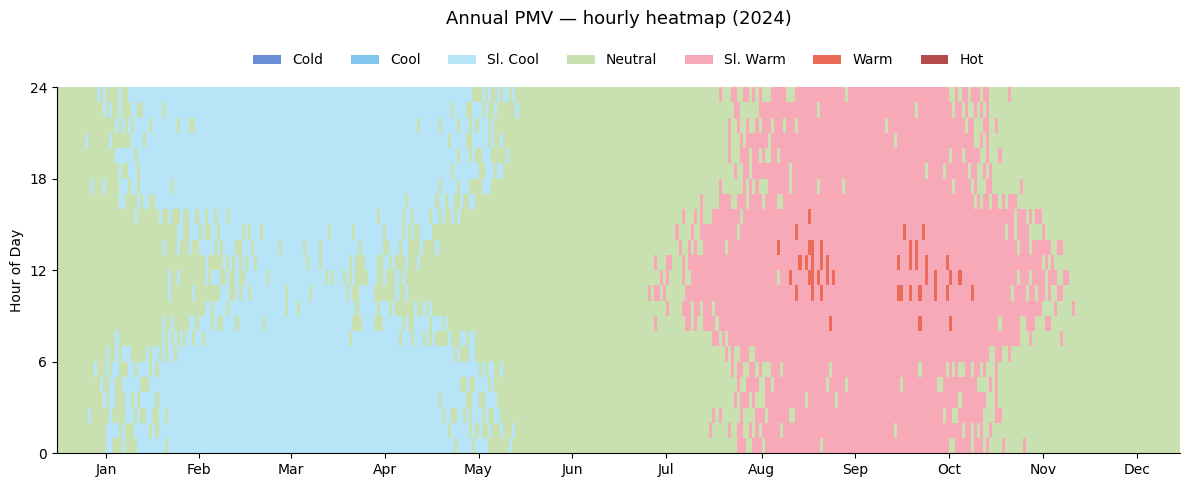

In [ ]:
result = (
    HeatmapPlot(df)
    .set_regions(
        output="pmv",
        thresholds=THRESHOLDS,
        labels=LABELS,
        colors=COLORS,
    )
    .plot(
        title="Annual PMV heatmap",
        x_label_format="month",
    )
)
plt.show()

## 4.  Heatmap + SummaryPlot side by side

Because both plots share the same `set_regions()` API we can pass identical region configurations and place the two charts next to each other for an annual overview.


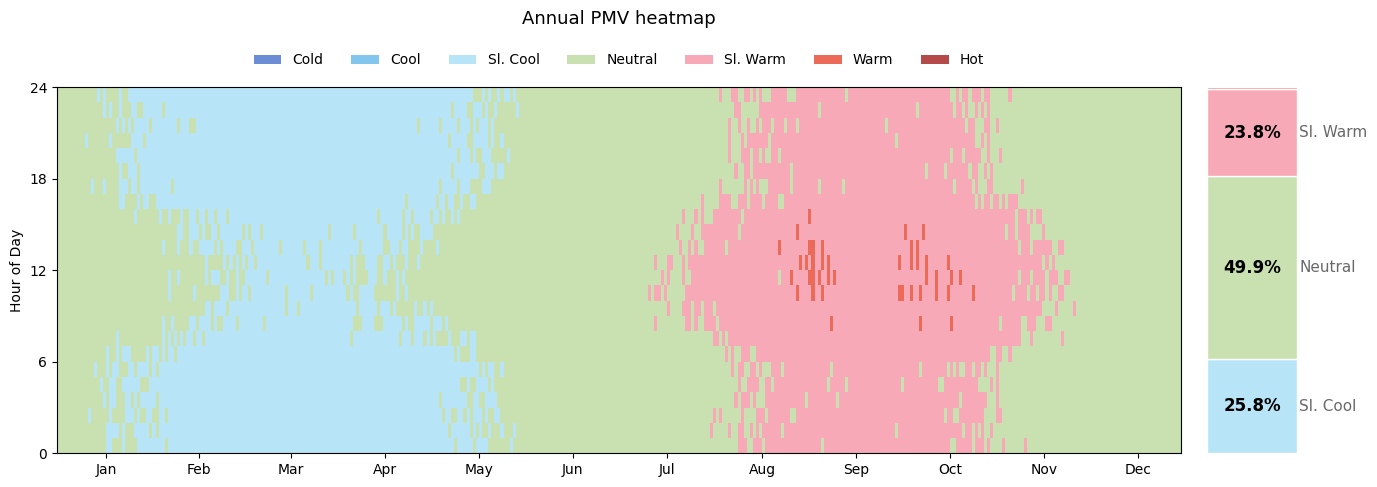

In [37]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [10, 1.4]},
)

region_kwargs = dict(
    output="pmv",
    thresholds=THRESHOLDS,
    labels=LABELS,
    colors=COLORS,
)

(
    HeatmapPlot(df)
    .set_regions(**region_kwargs)
    .plot(ax=axes[0], title="Annual PMV heatmap", legend=True)
)

(
    SummaryPlot(df)
    .set_regions(**region_kwargs)
    .plot(ax=axes[1], vertical=True, legend=False)
)

fig.tight_layout()
plt.show()


## 5.  Day-of-year label format

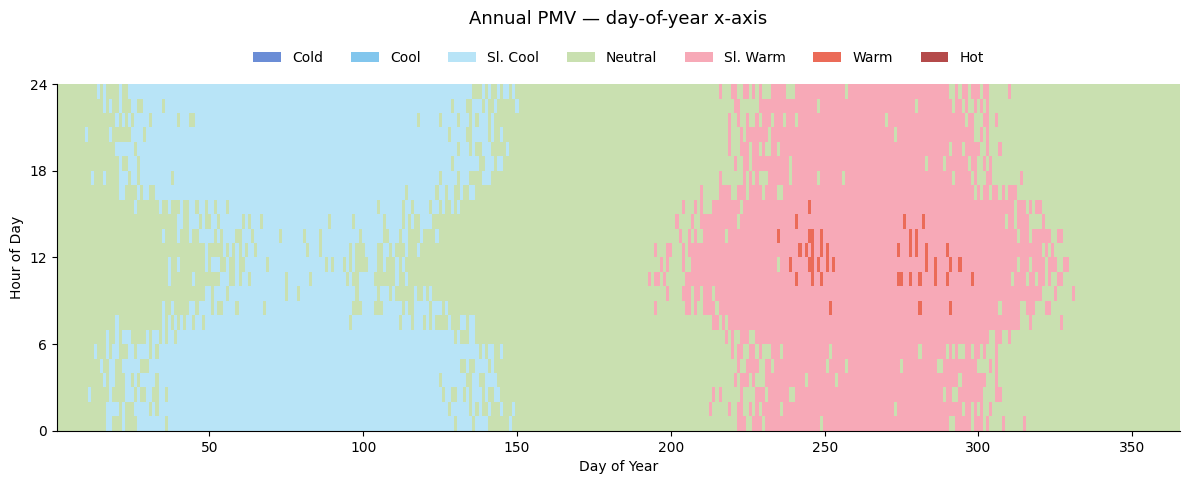

In [38]:
(
    HeatmapPlot(df)
    .set_regions(
        output="pmv",
        thresholds=THRESHOLDS,
        labels=LABELS,
        colors=COLORS,
    )
    .plot(
        title="Annual PMV — day-of-year x-axis",
        x_label_format="day",
    )
)
plt.show()

## 6.  NaN values shown as blank cells

Any gap in the data (e.g. a missing week) appears as white blank cells.

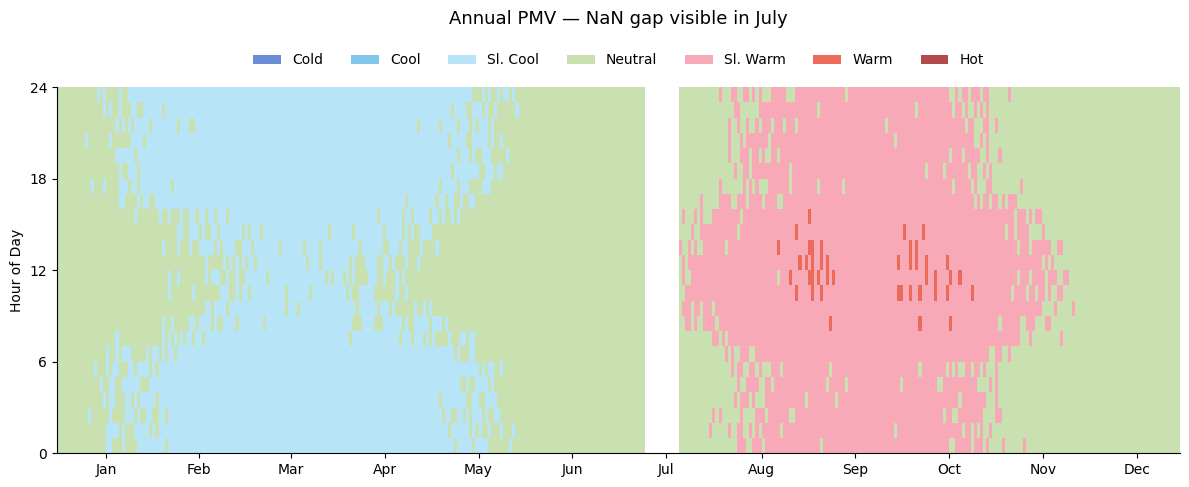

In [40]:
df_gaps = df.copy()
# Introduce a maintenance gap in July
df_gaps.loc["2024-07-10":"2024-07-20", "pmv"] = np.nan

(
    HeatmapPlot(df_gaps)
    .set_regions(
        output="pmv",
        thresholds=THRESHOLDS,
        labels=LABELS,
        colors=COLORS,
    )
    .plot(title="Annual PMV — NaN gap visible in July")
)
plt.show()

## 7.  Adaptive ASHRAE — naturally ventilated office (Mediterranean)

Example of a Mediterranean office building with natural ventilation. Indoor temperature follows the outdoor climate with some attenuation. The running mean outdoor temperature drives the ASHRAE adaptive comfort model; cells are coloured by **90% acceptability**, **80% acceptability** (but not 90%), and **uncomfortable** (outside the 80% band).

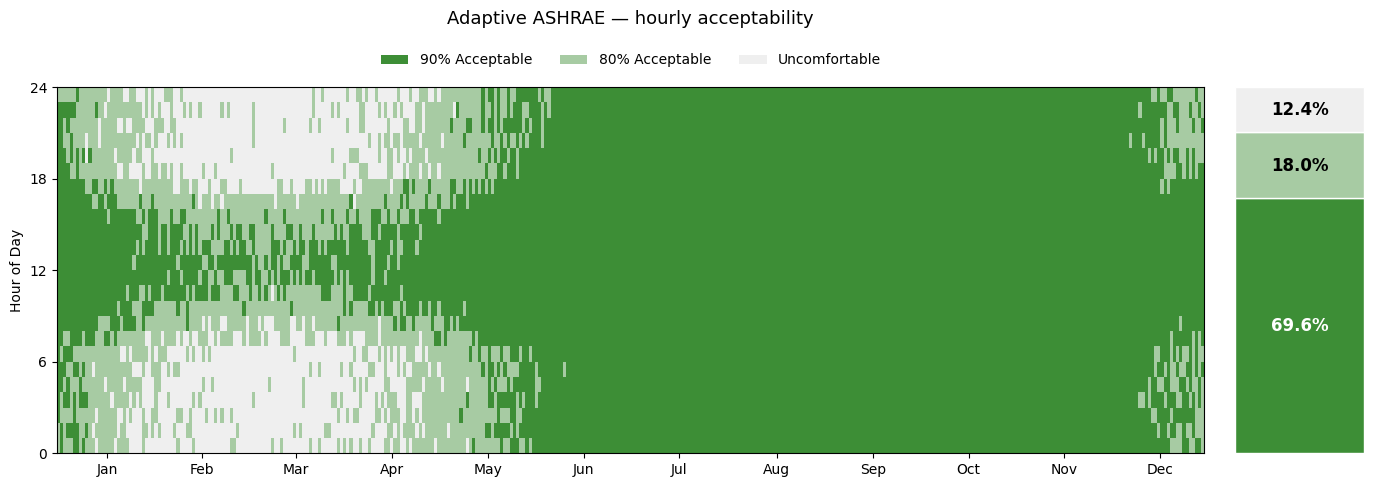

In [43]:
from pythermalcomfort.models import adaptive_ashrae

rng_a = np.random.default_rng(43)
doy_a  = index.day_of_year.to_numpy()
hour_a = index.hour.to_numpy()

# Outdoor temperature: warm Mediterranean (mean 18 °C, range 8–34 °C incl. diurnal)
t_out_a = (18 + 10 * np.sin(2 * np.pi * (doy_a - 172) / 365)
            +  6 * np.sin(2 * np.pi * (hour_a - 6) / 24).clip(min=0)
            + rng_a.normal(0, 0.5, 8760))

# Running mean (exponentially weighted daily mean, α = 0.1)
t_rm_daily = (pd.Series(t_out_a, index=index)
            .resample("D").mean()
            .ewm(alpha=0.1, adjust=False).mean())
t_rm_a = t_rm_daily.reindex(index, method="ffill").to_numpy()

# Indoor operative temperature: outdoor-moderated (17 °C winter → 27 °C summer)
t_in_a = (22 + 5 * np.sin(2 * np.pi * (doy_a - 172) / 365)
            + 1.5 * np.sin(2 * np.pi * (hour_a - 6) / 24).clip(min=0)
            + rng_a.normal(0, 0.3, 8760))

res_a = adaptive_ashrae(
    tdb=t_in_a.tolist(),
    tr=t_in_a.tolist(),
    t_running_mean=t_rm_a.tolist(),
    v=0.2,
)

# Encode acceptability: 0 = 90%, 1 = 80% (not 90%), 2 = uncomfortable
accept_90 = np.array(res_a.acceptability_90, dtype=bool)
accept_80 = np.array(res_a.acceptability_80, dtype=bool)
category  = np.where(accept_90, 0, np.where(accept_80, 1, 2)).astype(float)
df_adapt  = pd.DataFrame({"category": category}, index=index)

ADAPT_LABELS = ["90% Acceptable", "80% Acceptable", "Uncomfortable"]
ADAPT_COLORS = ["#3d8e36", "#a7cba3", "#efefef"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [10, 1.4]})
adapt_kw = dict(output="category", thresholds=[0.5, 1.5],
                labels=ADAPT_LABELS, colors=ADAPT_COLORS)

HeatmapPlot(df_adapt).set_regions(**adapt_kw).plot(
    ax=axes[0],
    title="Adaptive ASHRAE — hourly acceptability",
    legend=True,
)
SummaryPlot(df_adapt).set_regions(**{**adapt_kw, "labels": [""] * 3}).plot(
    ax=axes[1], vertical=True, legend=False,
)
fig.tight_layout()
plt.show()

## 8.  UTCI — outdoor thermal stress (warm-continental city)

Outdoor conditions for a warm-continental climate (e.g. Vienna / Budapest): strong seasonal swing, clear diurnal cycle with significant solar radiation gain. UTCI is coloured by the standard thermal stress categories.

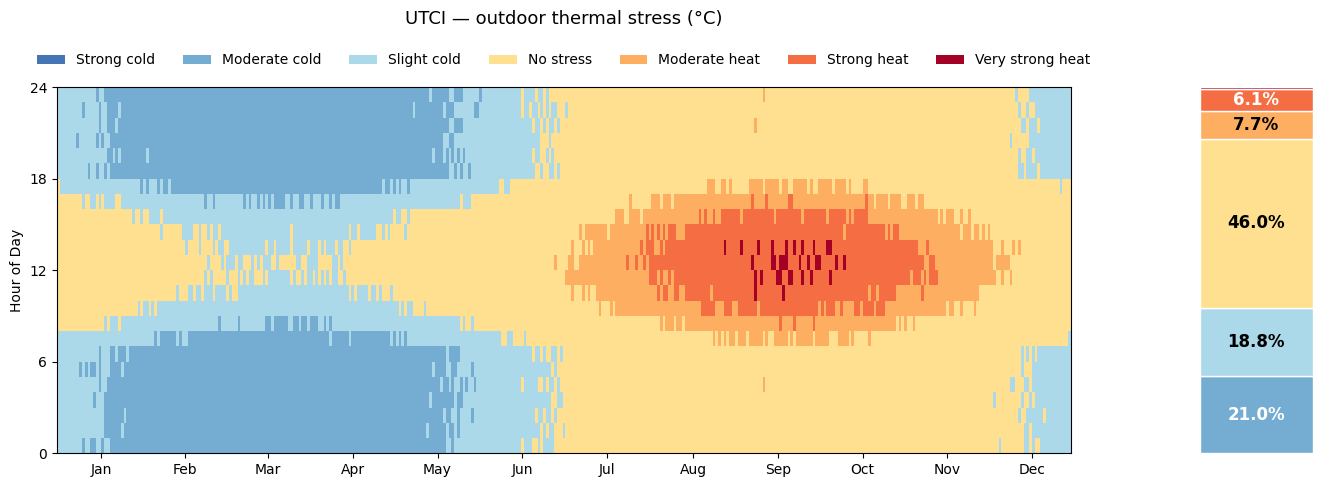

In [ ]:
from pythermalcomfort.models import utci

rng_u = np.random.default_rng(44)
doy_u  = index.day_of_year.to_numpy()
hour_u = index.hour.to_numpy()

# Outdoor air temperature: mean 10 °C, seasonal ±14 °C, diurnal ±7 °C
tdb_u = (10 + 14 * np.sin(2 * np.pi * (doy_u - 172) / 365)
            +  7 * np.sin(2 * np.pi * (hour_u - 6) / 24).clip(min=0)
            + rng_u.normal(0, 1, 8760))

# Mean radiant temperature: up to 25 °C above air temp at solar noon
tr_u = tdb_u + 25 * np.sin(2 * np.pi * (hour_u - 6) / 24).clip(min=0)

res_u = utci(tdb=tdb_u.tolist(), tr=tr_u.tolist(), v=2.0, rh=60)
df_utci = pd.DataFrame({"utci": np.array(res_u.utci, dtype=float)}, index=index)

UTCI_THRESHOLDS = [-13, 0, 9, 26, 32, 38]
UTCI_LABELS     = ["Strong cold", "Moderate cold", "Slight cold",
                "No stress", "Moderate heat", "Strong heat", "Very strong heat"]
UTCI_COLORS     = ["#4575b4", "#74add1", "#abd9e9",
                "#fee090", "#fdae61", "#f46d43", "#a50026"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [10, 1.4]})
utci_kw = dict(output="utci", thresholds=UTCI_THRESHOLDS,
            labels=UTCI_LABELS, colors=UTCI_COLORS)

HeatmapPlot(df_utci).set_regions(**utci_kw).plot(
    ax=axes[0],
    title="UTCI — outdoor thermal stress (°C)",
    legend=True,
)
SummaryPlot(df_utci).set_regions(**{**utci_kw, "labels": [""] * 7}).plot(
    ax=axes[1], vertical=True, legend=False,
)
fig.tight_layout()
plt.show()

## 9.  Heat Index — hot-humid outdoor climate (subtropical)

Heat Index for a subtropical coastal city (e.g. Miami / Houston).  The model
is only applicable above ~27 °C, so cooler winter/night hours appear as blank
cells — this is expected behaviour.

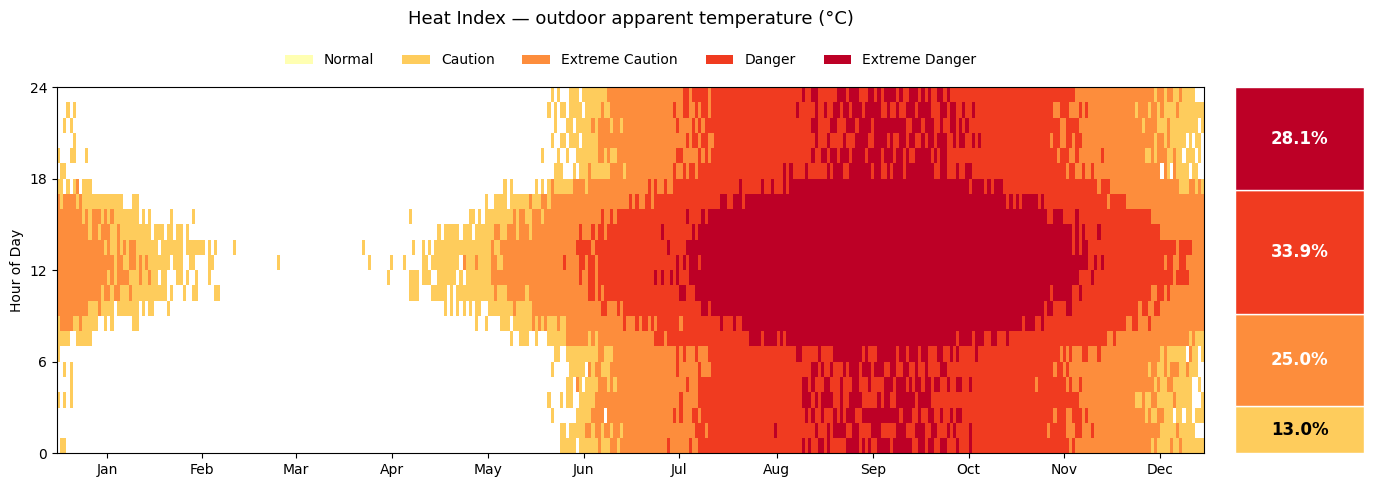

In [34]:
from pythermalcomfort.models import heat_index_rothfusz

rng_h = np.random.default_rng(45)
doy_h  = index.day_of_year.to_numpy()
hour_h = index.hour.to_numpy()

# Outdoor air temperature: warm year-round, hot humid summers
tdb_h = (28 + 6 * np.sin(2 * np.pi * (doy_h - 172) / 365)
            + 4 * np.sin(2 * np.pi * (hour_h - 6) / 24).clip(min=0)
            + rng_h.normal(0, 0.5, 8760))

# Relative humidity: higher in summer
rh_h = 75 + 10 * np.sin(2 * np.pi * (doy_h - 172) / 365)

res_h  = heat_index_rothfusz(tdb=tdb_h.tolist(), rh=rh_h.tolist())
df_hi  = pd.DataFrame({"hi": np.array(res_h.hi, dtype=float)}, index=index)

HI_THRESHOLDS = [27, 32, 41, 54]
HI_LABELS     = ["Normal", "Caution", "Extreme Caution", "Danger", "Extreme Danger"]
HI_COLORS     = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [10, 1.4]})
hi_kw = dict(output="hi", thresholds=HI_THRESHOLDS, labels=HI_LABELS, colors=HI_COLORS)

HeatmapPlot(df_hi).set_regions(**hi_kw).plot(
    ax=axes[0],
    title="Heat Index — outdoor apparent temperature (°C)",
    legend=True,
)
# SummaryPlot requires finite values — drop hours where HI is not applicable (<27 °C)
SummaryPlot(df_hi.dropna(subset=["hi"])).set_regions(**{**hi_kw, "labels": [""] * 5}).plot(
    ax=axes[1], vertical=True, legend=False,
)
fig.tight_layout()
plt.show()